In [9]:
import sys

import numpy as np
from pathlib import Path

# 'services', 'model_functions' e 'iSpec_functions' están en 'models', así que
# hay que poner esa carpeta en 'sys.path' antes de importarlos. Para eso
# localizamos 'solution' subiendo desde el directorio de trabajo, sin suponer
# dónde arranca el kernel: sirve tanto la carpeta de este cuaderno como 'models'
# o la raíz del repositorio. Su marca es el fichero 'pyproject.toml'. iSpec
# tampoco se instala como dependencia, pero de montarlo se encarga
# 'iSpec_functions', que lo añade a 'sys.path' al importarse.
SOLUTION_DIR = next(
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / "solution")
    if (candidate / "pyproject.toml").is_file()
)

sys.path.insert(0, str(SOLUTION_DIR / "models"))

from services.paths import DATA_DIR, model_paths, test_data_path

# Ficheros que deja el entrenamiento, nombrados por la convención que comparten
# todos los cuadernos y que reúne 'services/paths.py': el modelo en esta misma
# carpeta, por ser la salida del cuaderno; a su lado 'training' con el registro
# de cómo se entrenó; y fuera de ella las predicciones, en
# 'models/data/predictions', y la tabla del análisis con iSpec, en
# 'models/data/ispec_deviations': no son un checkpoint del entrenamiento sino
# el dato que consume la comparativa entre arquitecturas.
MODEL_PATH, HISTORY_PATH, SUMMARY_PATH, PREDICTIONS_PATH, ISPEC_PATH = (
    model_paths("snr", "snr")
)

# El conjunto de test que consumen las celdas de análisis va en
# 'models/data/test', carpeta común a todos los cuadernos porque todos parten
# del mismo conjunto de test. Esta celda no carga datos, de modo que la recarga
# de una sesión anterior solo necesita ejecutar esta celda y la de recarga.
TEST_DATA_PATH = test_data_path("snr")

# Tamaño de lote del entrenamiento, guardado también en el resumen
batch_size = 64

print("Carpeta de trabajo:", SOLUTION_DIR)

Carpeta de trabajo: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution


In [16]:
# El nombre del fichero puede llevar la fecha de generación como prefijo
candidates = (
    sorted(DATA_DIR.glob("*processed_data_no_duplicates.npz"))
    + sorted(DATA_DIR.glob("*processed_data.npz"))
)
processed_path = candidates[0]
print("Usando:", processed_path)

data = np.load(processed_path)

print(data.files)

['X_train', 'X_val', 'X_test', 'X_id_train', 'X_id_val', 'X_id_test', 'X_err_train', 'X_err_val', 'X_err_test', 'y_train', 'y_val', 'y_test', 'y_id_train', 'y_id_val', 'y_id_test', 'y_ivar_train', 'y_ivar_val', 'y_ivar_test', 'gaia_wavelength', 'sdss_wavelength']


In [17]:
# Datos de entrada Gaia
X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

# Errores de Gaia
X_err_train = data["X_err_train"]
X_err_val = data["X_err_val"]
X_err_test = data["X_err_test"]

# IDs de Gaia
X_id_train = data["X_id_train"]
X_id_val = data["X_id_val"]
X_id_test = data["X_id_test"]

# Datos objetivo SDSS
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

# IDs de SDSS
y_id_train = data["y_id_train"]
y_id_val = data["y_id_val"]
y_id_test = data["y_id_test"]

# Longitudes de onda
gaia_wavelength = data["gaia_wavelength"]
sdss_wavelength = data["sdss_wavelength"]

In [18]:
from services.normalization import normalize_splits

# Cada espectro se normaliza con la mediana de su propio flujo absoluto, tanto
# la entrada de Gaia como el objetivo de SDSS
X_train_norm, X_val_norm, X_test_norm, X_scale_test = normalize_splits(
    X_train, X_val, X_test
)
y_train_norm, y_val_norm, y_test_norm, y_scale_test = normalize_splits(
    y_train, y_val, y_test
)

In [19]:
X_err_train_scaled = X_err_train / 1e-19
X_err_val_scaled = X_err_val / 1e-19
X_err_test_scaled = X_err_test / 1e-19
eps = 1e-8

In [20]:
snr_train = np.abs(X_train) / (X_err_train_scaled + eps)
snr_val = np.abs(X_val) / (X_err_val_scaled + eps)
snr_test = np.abs(X_test) / (X_err_test_scaled + eps)

In [21]:
snr_p99 = np.nanpercentile(snr_train, 99)

snr_train = np.clip(snr_train, 0, snr_p99)
snr_val = np.clip(snr_val, 0, snr_p99)
snr_test = np.clip(snr_test, 0, snr_p99)

In [22]:
from services.normalization import standardize_splits

# La SNR no se normaliza por espectro sino píxel a píxel, con la media y la
# desviación típica del conjunto de entrenamiento
(snr_train_norm, snr_val_norm, snr_test_norm,
 snr_mean, snr_std) = standardize_splits(snr_train, snr_val, snr_test, axis=0)

In [23]:
X_model_with_snr_train = np.concatenate(
    [X_train_norm, snr_train_norm],
    axis=1
)

X_model_with_snr_val = np.concatenate(
    [X_val_norm, snr_val_norm],
    axis=1
)

X_model_with_snr_test = np.concatenate(
    [X_test_norm, snr_test_norm],
    axis=1
)

print("X_train_norm:", X_train_norm.shape)
print("snr_train_norm:", snr_train_norm.shape)
print("Entrada final:", X_model_with_snr_train.shape)

X_train_norm: (32656, 201)
snr_train_norm: (32656, 201)
Entrada final: (32656, 402)


In [29]:
from services.checkpoints import save_test_data

# Guardamos las variables del conjunto de test que consumen las celdas
# posteriores al entrenamiento, para poder ejecutarlas sin repetir estas celdas.
# La entrada del modelo sí se guarda: reconstruirla exige los estadísticos de la
# SNR del conjunto de entrenamiento, que solo salen del `.npz` de datos completo.
save_test_data(
    TEST_DATA_PATH,
    X_test=X_test,
    y_test=y_test,
    X_id_test=X_id_test,
    y_id_test=y_id_test,
    gaia_wavelength=gaia_wavelength,
    sdss_wavelength=sdss_wavelength,
    y_scale_test=y_scale_test,
    X_model_with_snr_test=X_model_with_snr_test
)

2026-09-03 16:51:14.950871: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-03 16:51:15.063735: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-03 16:51:17.595107: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/data/test/snr_test_data.npz')

In [24]:

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

n_gaia = X_model_with_snr_train.shape[1]
n_sdss = y_train.shape[1]

model_snr = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),#, activation="elu"),#relu
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model_snr.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_snr.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │       206,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,563,498 (21.22 MB)

 Trainable params: 5,563,498 (21.22 MB)

 Non-trainable params: 0 (0.00 B)

El entrenamiento deja cuatro ficheros, uno por cada forma de dato: en `models/snr`, el modelo, que es la salida del cuaderno, y a su lado `training` con el registro de cómo se entrenó; y en `models/data/test`, carpeta común a todos los cuadernos, el conjunto de test, con los que las celdas de evaluación y análisis pueden ejecutarse en una sesión nueva sin repetir el entrenamiento ni volver a cargar el `.npz` de datos completo:

- `snr.keras`: el modelo con la mejor pérdida de validación, guardado cada vez que mejora.
- `training/snr_training_history.csv`: una fila por época con todas las métricas, escrita al final de cada época. Es una **tabla**, así que la escribe directamente el callback `CSVLogger` de Keras, sin código propio, y queda legible y comparable con la de los demás modelos. Un CSV además admite los `NaN` de una época divergente, que en JSON no serían válidos.
- `training/snr_training_summary.json`: el resumen del entrenamiento (mejor época, tamaño de lote y métricas de test). Son **datos sueltos y heterogéneos** que no caben en una tabla ni en un contenedor de arrays, y en JSON siguen siendo legibles y versionables en Git.
- `models/data/test/snr_test_data.npz`: las variables del conjunto de test que consumen las celdas posteriores (`X_test`, `y_test`, los identificadores, las longitudes de onda, la escala de normalización y la entrada del modelo con la SNR concatenada). Son **arrays** de cientos de megabytes, para los que `.npz` es el único formato razonable de los tres: conserva forma y `dtype` sin código de conversión y se escribe y lee en menos de un segundo, mientras que en JSON o CSV los mismos datos ocuparían varias veces más en texto. Sobre todo, conserva los identificadores de Gaia como `int64`: son de hasta 19 dígitos y más de la mitad no se representan de forma exacta en el `float64` al que los llevaría un CSV o un JSON leído como decimal.

La lógica de guardado y recarga vive en `models/services/checkpoints.py`, compartida por todos los cuadernos de entrenamiento. De la normalización se ocupa `models/services/normalization.py`, que reúne los esquemas de todos los cuadernos. Los arrays que se regeneran en un paso determinista, como las predicciones del modelo, no se guardan: se obtienen del modelo y del propio `.npz` de test.

In [25]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5, # 4 EN SU OPTIMO ESTADO, 
    min_delta = 1e-4,
    restore_best_weights=True
)

from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint

from services.checkpoints import save_training_summary

# Checkpoint del modelo: conserva los pesos de la mejor época de validación
save_best_epoch_model = ModelCheckpoint(
    MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Checkpoint del historial: añade una fila al final de cada época
save_training_history = CSVLogger(HISTORY_PATH)

history = model_snr.fit(
    X_model_with_snr_train,
    y_train_norm,
    validation_data=(X_model_with_snr_val, y_val_norm),
    epochs=50,
    batch_size=batch_size, #32 PARA QUE VAYA EN SU OPTIMO ESTADO
    callbacks=[
        save_best_epoch_model,
        early_stop,
        reduce_lr,
        save_training_history
    ],
    verbose=1
)

# `EarlyStopping` restaura los mejores pesos: los fijamos en el checkpoint final
model_snr.save(MODEL_PATH)

model_data_snr = history.history
save_training_summary(
    SUMMARY_PATH,
    model_data_snr,
    model_path=MODEL_PATH,
    history_path=HISTORY_PATH,
    batch_size=batch_size
)

Epoch 1/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - loss: 0.0671 - mae: 0.1999 - mse: 0.1508 - val_loss: 0.0049 - val_mae: 0.0574 - val_mse: 0.0148 - learning_rate: 1.0000e-04
Epoch 2/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - loss: 0.0047 - mae: 0.0545 - mse: 0.0122 - val_loss: 0.0046 - val_mae: 0.0533 - val_mse: 0.0141 - learning_rate: 1.0000e-04
Epoch 3/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - loss: 0.0044 - mae: 0.0520 - mse: 0.0115 - val_loss: 0.0043 - val_mae: 0.0503 - val_mse: 0.0134 - learning_rate: 1.0000e-04
Epoch 4/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - loss: 0.0043 - mae: 0.0507 - mse: 0.0115 - val_loss: 0.0040 - val_mae: 0.0491 - val_mse: 0.0129 - learning_rate: 1.0000e-04
Epoch 5/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - loss: 0.0040 - mae: 0.0490 - mse: 0.0105 - val_loss: 0.0039 - val_mae: 0.0485 - val_mse: 0.0125 - learning_rate: 1.0000e-04
Epoch 6/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - loss: 0.0038 - mae: 0.0485 - mse: 0.0097 - v

Recarga desde el checkpoint. Esta celda recupera de los cuatro ficheros todas las variables que necesitan las celdas siguientes: el modelo, el historial, el resumen con las métricas de test y las variables del conjunto de test. Ejecutando la primera celda del cuaderno —la de rutas, que no carga datos— y después esta, el resto del análisis funciona sin reentrenar y sin volver a cargar el `.npz` de datos completo.

In [3]:
from services.checkpoints import load_checkpoint, load_test_data
from services.normalization import normalize

model_snr, model_data_snr, training_summary = load_checkpoint(
    MODEL_PATH, HISTORY_PATH, SUMMARY_PATH
)

# Variables del conjunto de test que consumen las celdas siguientes
test_data = load_test_data(TEST_DATA_PATH)

X_test = test_data["X_test"]
y_test = test_data["y_test"]
X_id_test = test_data["X_id_test"]
y_id_test = test_data["y_id_test"]
gaia_wavelength = test_data["gaia_wavelength"]
sdss_wavelength = test_data["sdss_wavelength"]
y_scale_test = test_data["y_scale_test"]
X_model_with_snr_test = test_data["X_model_with_snr_test"]

# El objetivo normalizado se rehace en un paso a partir de su escala
y_test_norm = normalize(y_test, y_scale_test)

print("Checkpoint de", training_summary["updated"])
print(
    "Épocas completadas:", training_summary["epochs_completed"],
    "| mejor época:", training_summary["best_epoch"]
)
print("Métricas de test:", training_summary["test_metrics"])

2026-09-03 13:07:18.163698: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Checkpoint de 2026-09-03T11:01:59
Épocas completadas: 17 | mejor época: 17
Métricas de test: {'loss': 0.003063637064769864, 'mae': 0.042416997253894806, 'mse': 0.007809039205312729}


In [26]:
from services.normalization import denormalize
from services.predictions import predict_test_set, save_predictions

# Predicciones sobre el conjunto de test. La celda parte del `.keras` del modelo
# y del `.npz` de test, así que se ejecuta suelta tras la de rutas: no
# reentrena, no vuelve a cargar el `.npz` de datos completo y no necesita las
# variables que dejen en memoria las demás celdas del cuaderno.
y_pred = predict_test_set(
    MODEL_PATH,
    TEST_DATA_PATH,
    # La entrada va guardada en el `.npz` de test: rehacerla exige los
    # estadísticos de la SNR del conjunto de entrenamiento
    build_input=lambda test: test["X_model_with_snr_test"],
    denormalize=lambda y_norm, test: denormalize(y_norm, test["y_scale_test"])
)

# Las guardamos para la comparativa entre arquitecturas, en su propio cuaderno
save_predictions(PREDICTIONS_PATH, y_pred=y_pred)

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [27]:
from services.checkpoints import save_training_summary

test_metrics = model_snr.evaluate(
    X_model_with_snr_test,
    y_test_norm,
    verbose=1,
    return_dict=True
)

# Las métricas de test se añaden al resumen del entrenamiento
save_training_summary(
    SUMMARY_PATH,
    model_data_snr,
    test_metrics,
    model_path=MODEL_PATH,
    history_path=HISTORY_PATH,
    batch_size=batch_size
)

print(test_metrics)

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0031 - mae: 0.0424 - mse: 0.0089


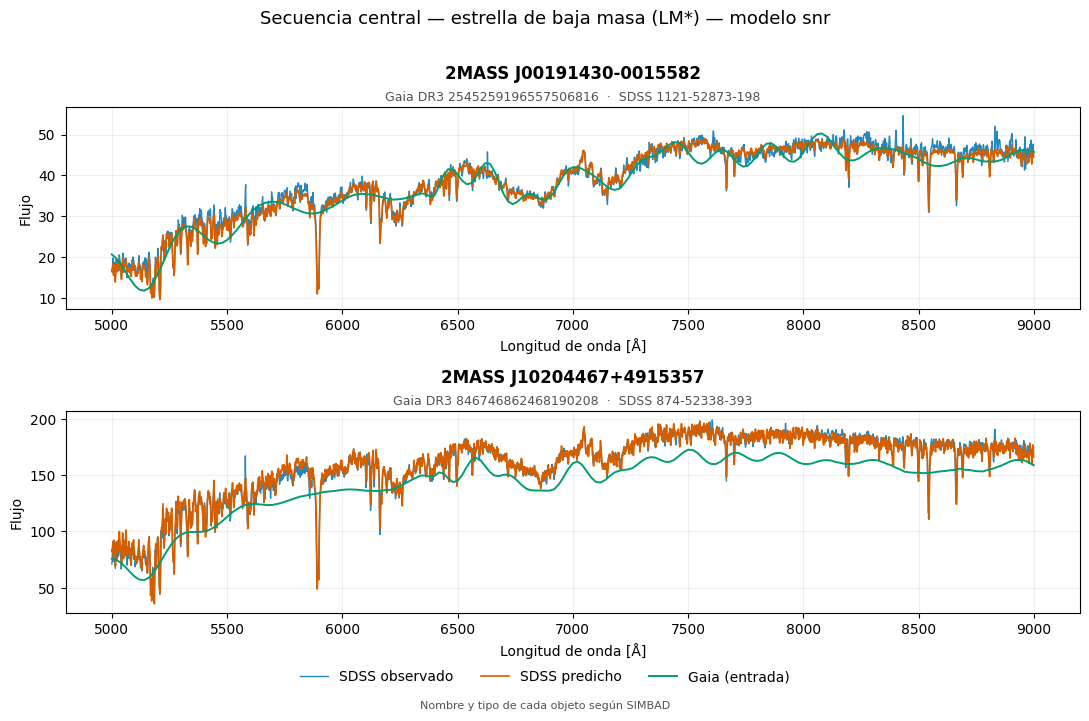

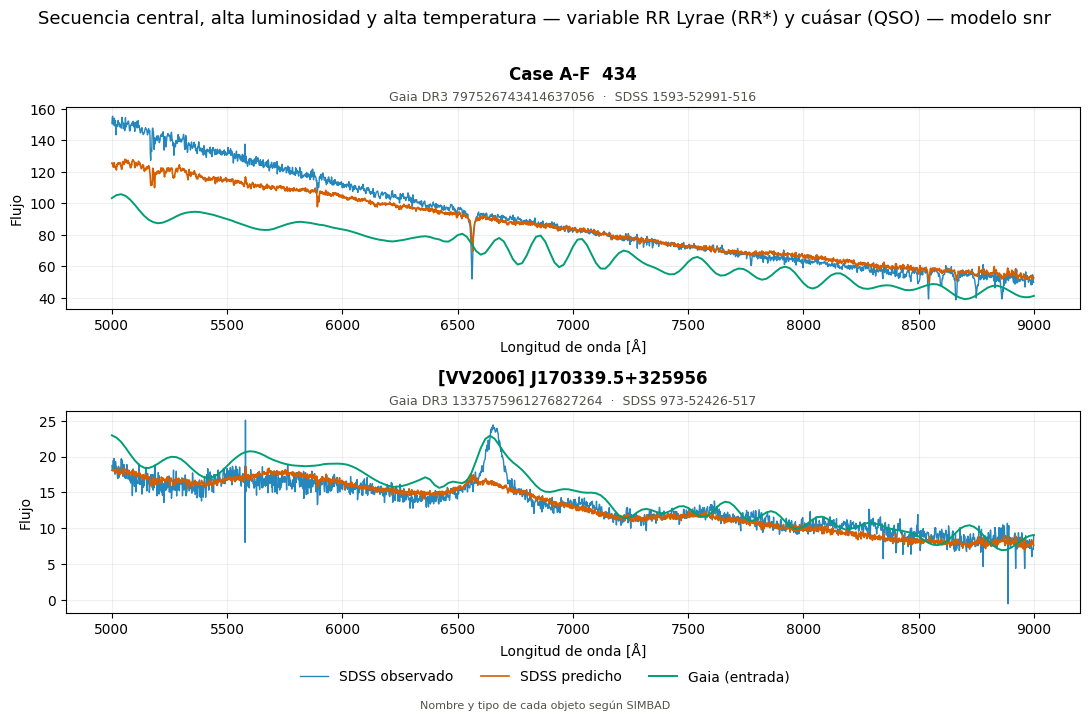

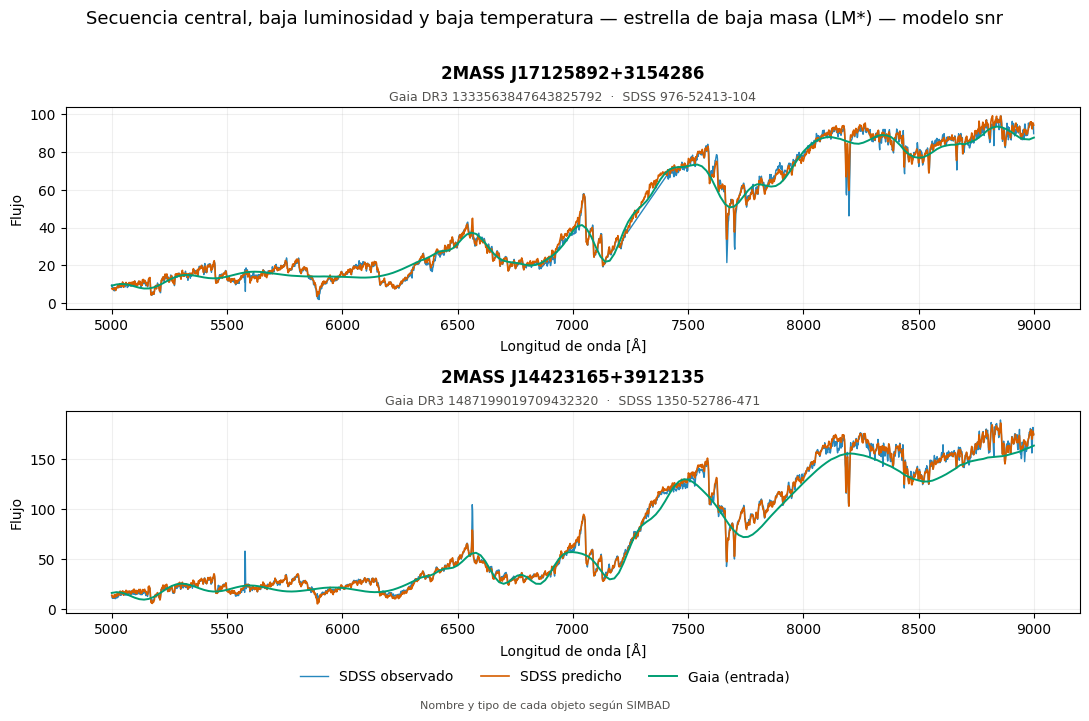

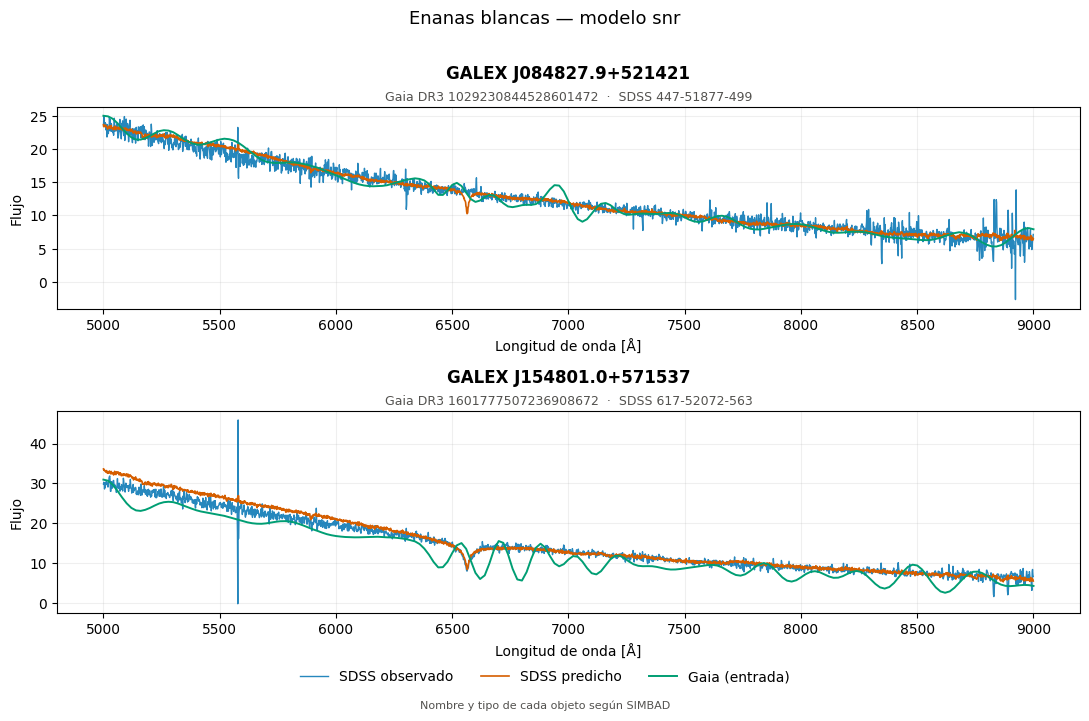

Imágenes guardadas en /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images


[PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/snr_main_sequence_central.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/snr_main_sequence_left.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/snr_main_sequence_right.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/snr_white_dwarfs.png')]

In [2]:
import sys

# 'plotting.py' vive en 'solution/services', y la celda de rutas solo añade
# 'models' a 'sys.path'. Las dos carpetas se llaman 'services', así que Python
# las une en un único paquete del que salen tanto 'services.paths' como
# 'services.plotting'
sys.path.insert(0, str(SOLUTION_DIR))

from services.plotting import SELECTED_OBJECTS_PATH, plot_selected_objects

# Comparativa sobre los mismos objetos en todos los cuadernos: la pareja de
# cada zona del diagrama HR que eligió 'services/simbad.py', encabezada por el
# nombre celeste oficial de cada objeto. Las figuras quedan guardadas en
# 'models/images' con el nombre que cita la memoria.
#
# La celda parte del CSV de objetos y de los `.npz` de test y de predicciones,
# así que se ejecuta suelta tras la de rutas: no reentrena, no vuelve a cargar
# el `.npz` de datos completo y no necesita las variables que dejen en memoria
# las demás celdas del cuaderno.
plot_selected_objects(
    SELECTED_OBJECTS_PATH,
    TEST_DATA_PATH,
    PREDICTIONS_PATH,
    "snr"
)


Validación física con iSpec: analizamos una muestra de espectros de test comparando los parámetros estelares (Teff, log g, [M/H]) derivados del espectro SDSS real frente a los derivados del espectro predicho por la red.

El proceso se reparte en tres celdas independientes —importaciones, recursos y análisis— para que repetir el análisis, que es con diferencia lo más lento, no vuelva a cargar los recursos.

Las predicciones las relee la celda del análisis del `.npz` que deja la celda de predicción, de modo que el análisis se ejecuta en una sesión nueva tras la celda de rutas, sin cargar el modelo ni depender del orden en que se hayan lanzado las demás celdas.

In [4]:
# Funciones de iSpec (el módulo está en 'models', ya añadido a sys.path)
from iSpec_functions import (
    load_ispec_resources,
    load_gaia_table,
    analyze_sample_real_vs_pred,
    analyze_ispec_errors
)

In [5]:
# Recursos de iSpec y tabla de Gaia. Las dos cargas están cacheadas en
# 'iSpec_functions', de modo que repetir esta celda no vuelve a leer de disco
resources = load_ispec_resources()

gaia_data_df = load_gaia_table()

/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/lib/iSpec/ispec/atmospheres.py:349: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  delaunay_triangulations, kdtree = pickle.load(open(cache_filename, 'rb'))



Recursos de iSpec cargados correctamente.
Tabla de Gaia cargada: 121890 objetos.


Espectros analizados:   0%|          | 0/250 [00:00<?, ?cuerpos estelares/s]

Error analizando el espectro real de 2538096737295072384: Initial teff '3463.60498046875' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 1541549494377790976: Initial Vmac '69.0' is out of range: '0.0' - '50.0'
Error analizando el espectro real de 1580491584892970880: Initial teff '3470.390380859375' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 705041494643881984: Initial Vmac '99.79' is out of range: '0.0' - '50.0'
Error analizando el espectro real de 2545605714518955904: Initial teff '3458.80908203125' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 3123413192472575104: Initial Vmac '61.38' is out of range: '0.0' - '50.0'
Error analizando el espectro real de 2543233827419669248: Initial teff '3367.34033203125' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 1314845963554562048: Initial teff '3131.83984375' is out of range: '3500.0' - '50000.0'
Error analizando el espectro re

[2026-09-03 13:21:57,274] [WARNING] [atmospheres:_interpolate:110]: Target point '6889.0402278552665 4.397491689556806 -5.5 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-09-03 13:21:58,351] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.


Error analizando el espectro real de 3265951891326617984: Initial teff '3302.129150390625' is out of range: '3500.0' - '50000.0'
Espectros analizados: 250 | ajustes reutilizados: 250 reales, 243 predichos


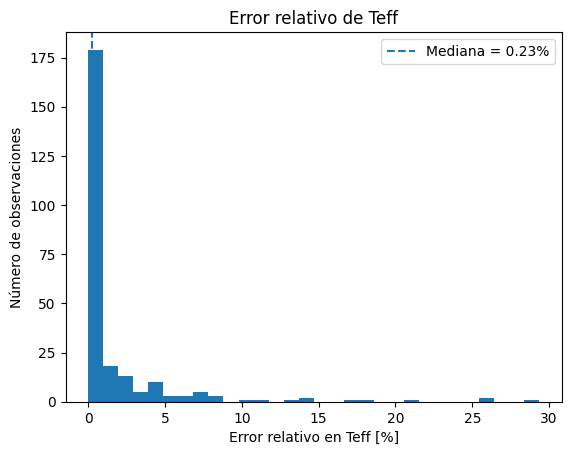

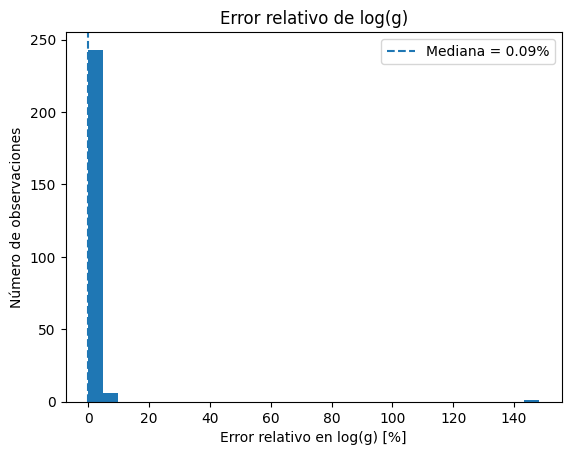

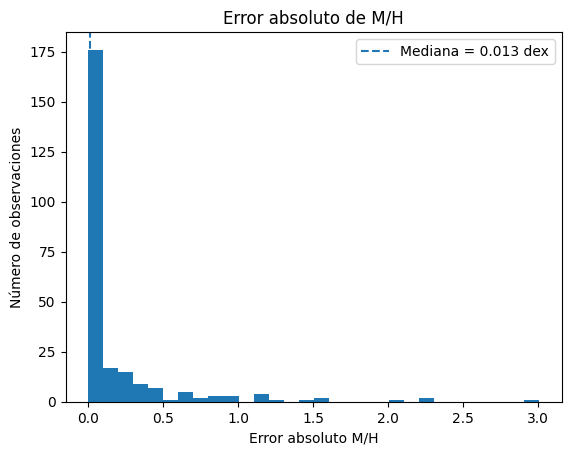

In [12]:
from services.predictions import load_predictions

# Releemos las predicciones de su `.npz` en lugar de esperarlas en memoria, para
# que esta celda se ejecute suelta tras la de rutas y las de iSpec, sin pasar por
# la celda de predicción. La escribe esa misma celda nada más predecir, así que
# el fichero corresponde siempre al último modelo guardado.
y_pred = load_predictions(PREDICTIONS_PATH)["y_pred"]

# Analizamos con iSpec una muestra de espectros reales frente a predichos
results_df_snr = analyze_sample_real_vs_pred(
    y_test,
    y_pred,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)

# Guardamos la tabla nada más calcularla: el análisis son horas de iSpec, y así
# los histogramas de error se rehacen sin repetirlo
ISPEC_PATH.parent.mkdir(parents=True, exist_ok=True)

results_df_snr.to_csv(
    ISPEC_PATH,
    index=False
)

error_df_snr = analyze_ispec_errors(results_df_snr)